# Market Basket Analysis — Visual Lecture Demo


In [1]:
import math
from itertools import combinations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import networkx as nx
from ipywidgets import interact, FloatSlider, IntSlider

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_colwidth", None)


## 1. Transaction data


In [2]:
transactions = {
    "T1": {"Beer", "Diaper", "Baby Powder", "Bread", "Umbrella"},
    "T2": {"Diaper", "Baby Powder"},
    "T3": {"Beer", "Diaper", "Milk"},
    "T4": {"Diaper", "Beer", "Detergent"},
    "T5": {"Beer", "Milk", "Coca-Cola"},
}

TIDs = list(transactions.keys())
T = list(transactions.values())
items = sorted(set().union(*T))
n = len(T)

df_tx = pd.DataFrame({
    "Transaction": TIDs,
    "Items": [", ".join(sorted(t)) for t in T]
})
display(df_tx)


,Transaction,Items
0,T1,"Baby Powder, Beer, Bread, Diaper, Umbrella"
1,T2,"Baby Powder, Diaper"
2,T3,"Beer, Diaper, Milk"
3,T4,"Beer, Detergent, Diaper"
4,T5,"Beer, Coca-Cola, Milk"


## 2. Basket → binary matrix


,Baby Powder,Beer,Bread,Coca-Cola,Detergent,Diaper,Milk,Umbrella
T1,1,1,1,0,0,1,0,1
T2,1,0,0,0,0,1,0,0
T3,0,1,0,0,0,1,1,0
T4,0,1,0,0,1,1,0,0
T5,0,1,0,1,0,0,1,0


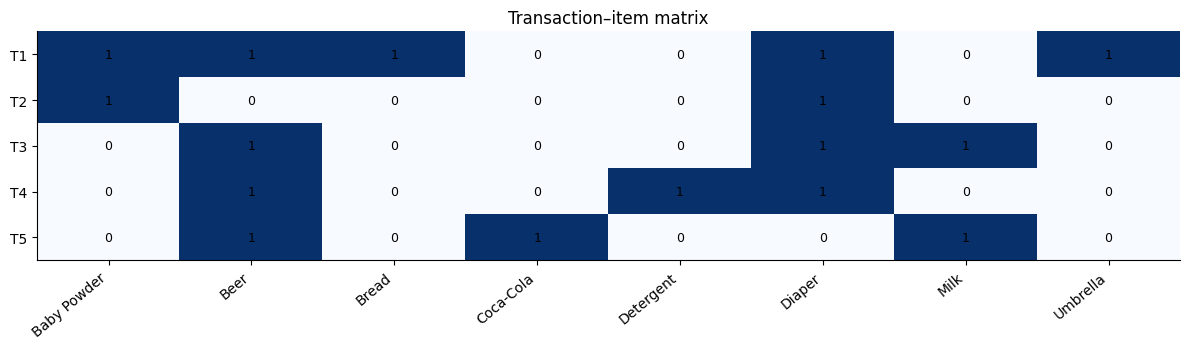

In [3]:
X = pd.DataFrame(0, index=TIDs, columns=items)
for tid, basket in transactions.items():
    for item in basket:
        X.loc[tid, item] = 1

display(X)

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.imshow(X.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(items)))
ax.set_xticklabels(items, rotation=40, ha="right")
ax.set_yticks(range(len(TIDs)))
ax.set_yticklabels(TIDs)
ax.set_title("Transaction–item matrix")
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        ax.text(j, i, int(X.iloc[i, j]), ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 3. Support and confidence


In [4]:
def support_count(itemset, trans=T):
    itemset = set(itemset)
    return sum(itemset.issubset(t) for t in trans)

def support(itemset, trans=T):
    return support_count(itemset, trans) / len(trans)

def confidence(X, Y, trans=T):
    X, Y = set(X), set(Y)
    denom = support_count(X, trans)
    return 0 if denom == 0 else support_count(X | Y, trans) / denom

X_rule = {"Beer"}
Y_rule = {"Diaper"}

both = support_count(X_rule | Y_rule)
onlyX = support_count(X_rule)
print("Beer -> Diaper")
print("support count(X ∪ Y) =", both)
print("support =", both, "/", n, "=", f"{both/n:.0%}")
print("confidence =", both, "/", onlyX, "=", f"{both/onlyX:.0%}")


Beer -> Diaper
support count(X ∪ Y) = 3
support = 3 / 5 = 60%
confidence = 3 / 4 = 75%


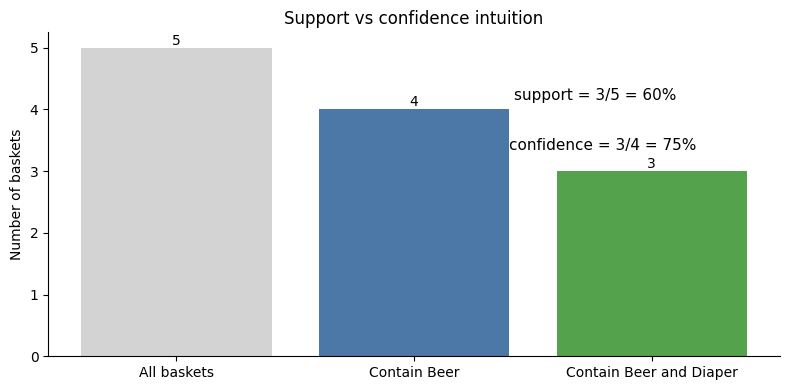

In [5]:
labels = ["All baskets", "Contain Beer", "Contain Beer and Diaper"]
values = [n, support_count({"Beer"}), support_count({"Beer", "Diaper"})]
colors = ["lightgray", "#4C78A8", "#54A24B"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, values, color=colors)
ax.set_ylabel("Number of baskets")
ax.set_title("Support vs confidence intuition")
for i, v in enumerate(values):
    ax.text(i, v + 0.05, str(v), ha="center")
ax.text(1.42, n*0.83, f"support = {both}/{n} = {both/n:.0%}", fontsize=11)
ax.text(1.40, n*0.67, f"confidence = {both}/{onlyX} = {both/onlyX:.0%}", fontsize=11)
plt.tight_layout()
plt.show()


## 4. Minimum support and frequent itemsets


,Item,Support count,Support,Frequent?
0,Beer,4,0.8,True
1,Diaper,4,0.8,True
2,Baby Powder,2,0.4,True
3,Milk,2,0.4,True
4,Bread,1,0.2,False
5,Coca-Cola,1,0.2,False
6,Detergent,1,0.2,False
7,Umbrella,1,0.2,False


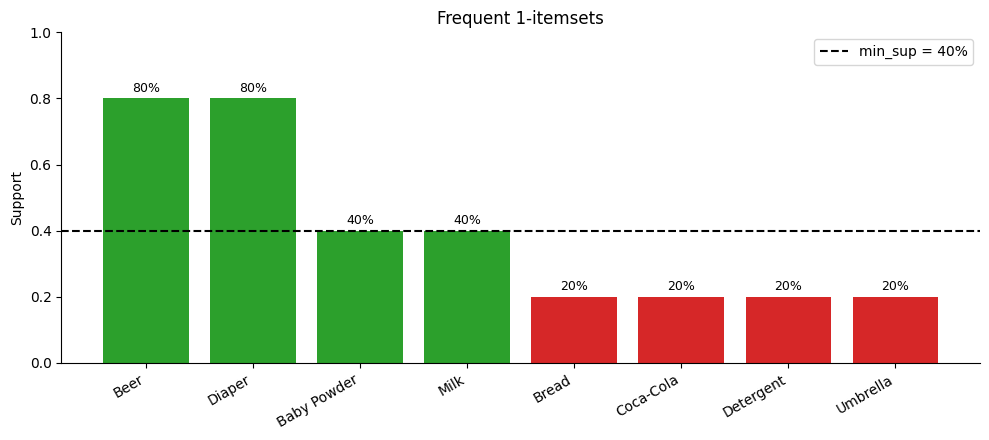

In [6]:
def frequent_1_itemsets(min_sup=0.4):
    min_count = math.ceil(min_sup * n)
    rows = []
    for i in items:
        cnt = support_count({i})
        rows.append({
            "Item": i,
            "Support count": cnt,
            "Support": cnt / n,
            "Frequent?": cnt >= min_count
        })
    return pd.DataFrame(rows).sort_values(["Support count", "Item"], ascending=[False, True]).reset_index(drop=True)

item_supports = frequent_1_itemsets(0.4)
display(item_supports)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#2ca02c" if f else "#d62728" for f in item_supports["Frequent?"]]
ax.bar(item_supports["Item"], item_supports["Support"], color=colors)
ax.axhline(0.4, linestyle="--", color="black", label="min_sup = 40%")
ax.set_ylim(0, 1)
ax.set_ylabel("Support")
ax.set_title("Frequent 1-itemsets")
ax.legend()
for i, v in enumerate(item_supports["Support"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 5. Candidate explosion


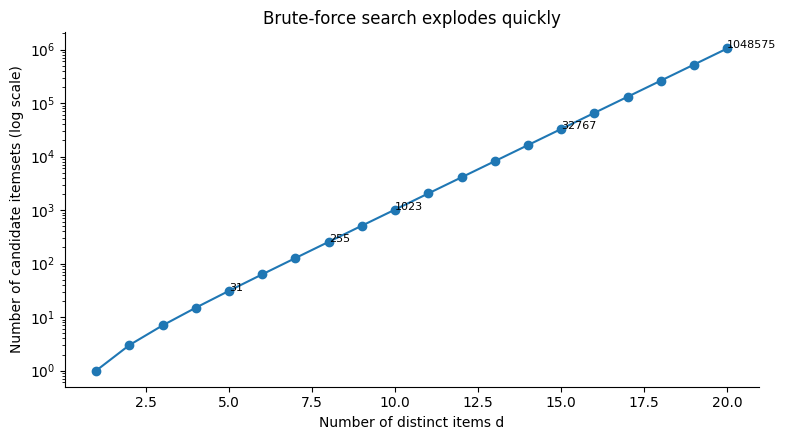

In [7]:
Ds = np.arange(1, 21)
Ms = 2**Ds - 1

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(Ds, Ms, marker="o")
ax.set_yscale("log")
ax.set_xlabel("Number of distinct items d")
ax.set_ylabel("Number of candidate itemsets (log scale)")
ax.set_title("Brute-force search explodes quickly")
for d in [5, 8, 10, 15, 20]:
    ax.text(d, 2**d - 1, f"{2**d - 1}", fontsize=8)
plt.tight_layout()
plt.show()


## 6. Apriori principle


In [8]:
example_items = ["Beer", "Diaper", "Milk", "Bread"]
bad = {"Beer", "Bread"}
supersets = [
    set(s) for r in range(len(bad)+1, len(example_items)+1)
    for s in combinations(example_items, r) if bad.issubset(s)
]

print("Assume infrequent:", tuple(sorted(bad)))
print("Then prune all supersets:")
for s in supersets:
    print(" ", tuple(sorted(s)))


Assume infrequent: ('Beer', 'Bread')
Then prune all supersets:
  ('Beer', 'Bread', 'Diaper')
  ('Beer', 'Bread', 'Milk')
  ('Beer', 'Bread', 'Diaper', 'Milk')


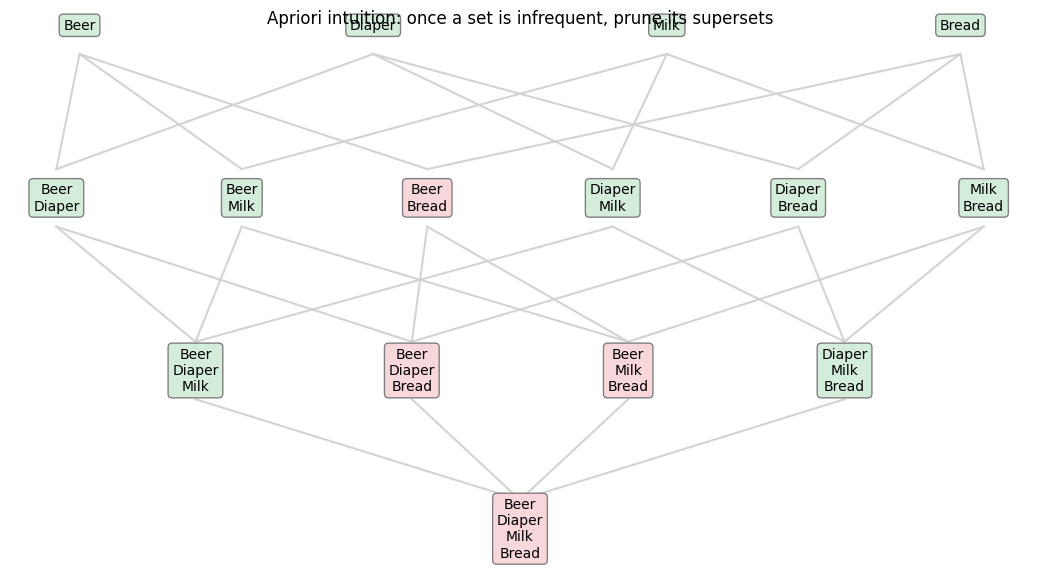

In [9]:
levels = {k: list(combinations(example_items, k)) for k in range(1, len(example_items)+1)}
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.axis("off")
xs = {
    1: np.linspace(0.12, 0.88, len(levels[1])),
    2: np.linspace(0.10, 0.90, len(levels[2])),
    3: np.linspace(0.22, 0.78, len(levels[3])),
    4: np.array([0.5]),
}
ys = {1: 0.82, 2: 0.58, 3: 0.34, 4: 0.12}
pos = {}

for k, combs in levels.items():
    for x, comb in zip(xs[k], combs):
        pos[(k, comb)] = (x, ys[k])
        s = set(comb)
        color = "#f8d7da" if (s == bad or bad.issubset(s)) else "#d4edda"
        ax.text(x, ys[k], "\n".join(comb), ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=color, edgecolor="gray"))

for k in range(1, 4):
    for small in levels[k]:
        x1, y1 = pos[(k, small)]
        for big in levels[k+1]:
            if set(small).issubset(set(big)):
                x2, y2 = pos[(k+1, big)]
                ax.plot([x1, x2], [y1-0.04, y2+0.04], color="lightgray", zorder=0)

ax.set_title("Apriori intuition: once a set is infrequent, prune its supersets")
plt.tight_layout()
plt.show()


## 7. Apriori step-by-step


In [10]:
def candidate_itemsets(prev_frequents, k):
    prev = sorted([tuple(sorted(s)) for s in prev_frequents])
    prev_set = set(prev)
    cands = set()
    for i in range(len(prev)):
        for j in range(i + 1, len(prev)):
            u = tuple(sorted(set(prev[i]) | set(prev[j])))
            if len(u) == k and all(tuple(sorted(sub)) in prev_set for sub in combinations(u, k - 1)):
                cands.add(u)
    return sorted(cands)

def itemset_table(candidates, min_sup=0.4):
    min_count = math.ceil(min_sup * n)
    rows = []
    for c in candidates:
        cnt = support_count(c)
        rows.append({
            "Itemset": ", ".join(c),
            "Support count": cnt,
            "Support": f"{cnt}/{n}",
            "Frequent?": "Yes" if cnt >= min_count else "No"
        })
    return pd.DataFrame(rows, columns=["Itemset", "Support count", "Support", "Frequent?"])

def apriori_levels(min_sup=0.4):
    min_count = math.ceil(min_sup * n)
    C1 = [(i,) for i in items]
    L1 = [c for c in C1 if support_count(c) >= min_count]

    C2 = list(combinations([c[0] for c in L1], 2))
    L2 = [c for c in C2 if support_count(c) >= min_count]

    C3 = candidate_itemsets(L2, 3)
    L3 = [c for c in C3 if support_count(c) >= min_count]
    return C1, L1, C2, L2, C3, L3

C1, L1, C2, L2, C3, L3 = apriori_levels(0.4)

print("C1 =", C1)
print("L1 =", L1)
print("C2 =", C2)
print("L2 =", L2)
print("C3 =", C3)
print("L3 =", L3)


C1 = [('Baby Powder',), ('Beer',), ('Bread',), ('Coca-Cola',), ('Detergent',), ('Diaper',), ('Milk',), ('Umbrella',)]
L1 = [('Baby Powder',), ('Beer',), ('Diaper',), ('Milk',)]
C2 = [('Baby Powder', 'Beer'), ('Baby Powder', 'Diaper'), ('Baby Powder', 'Milk'), ('Beer', 'Diaper'), ('Beer', 'Milk'), ('Diaper', 'Milk')]
L2 = [('Baby Powder', 'Diaper'), ('Beer', 'Diaper'), ('Beer', 'Milk')]
C3 = []
L3 = []


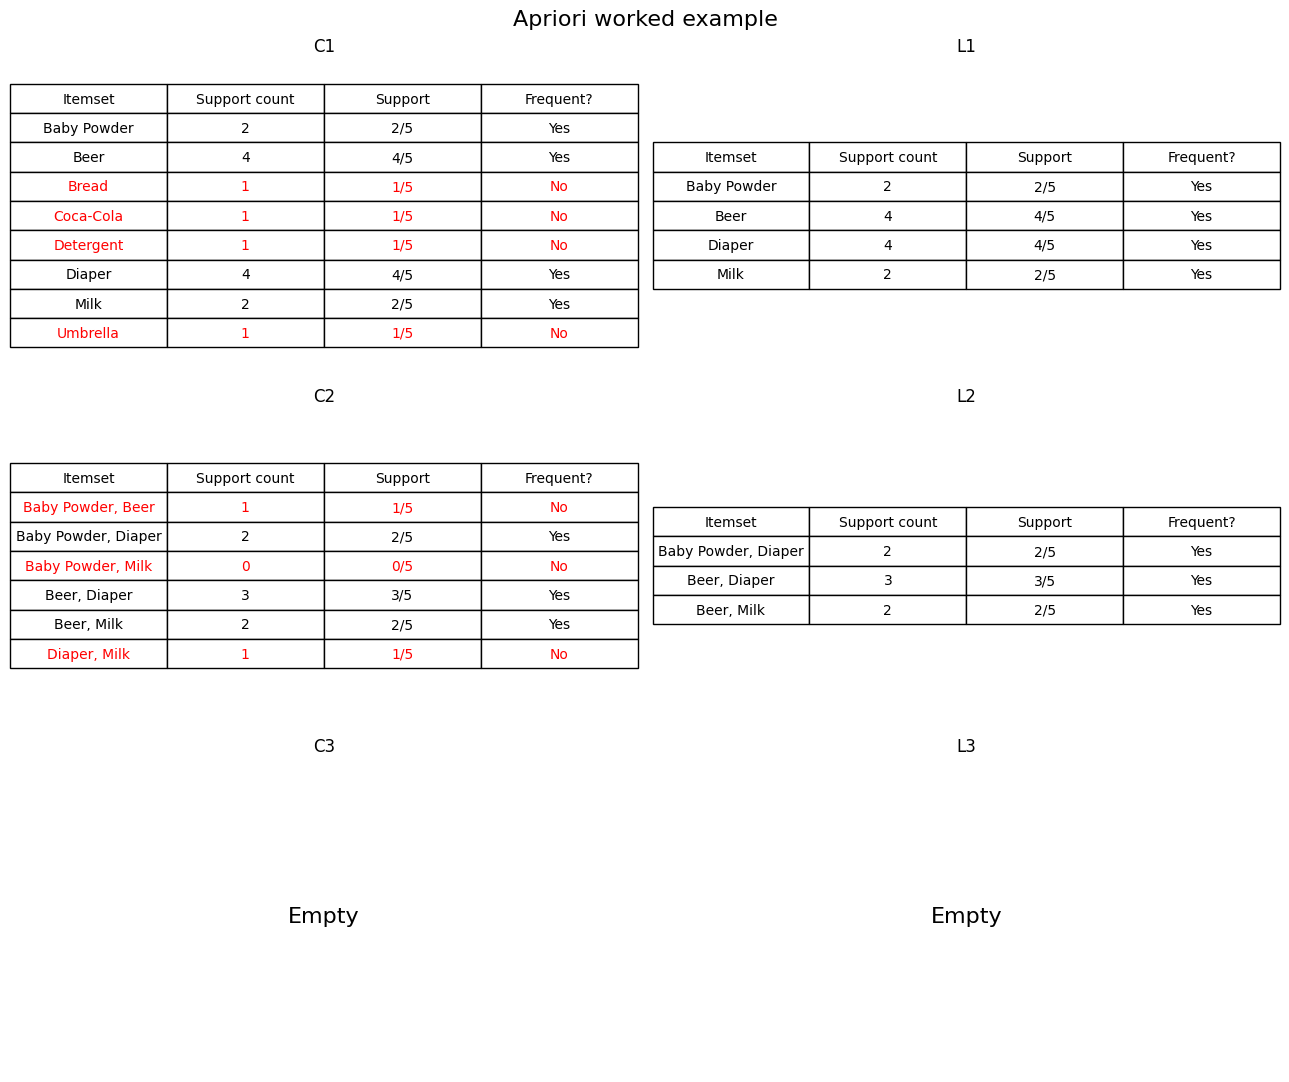

In [11]:
C1_df = itemset_table(C1, 0.4)
L1_df = itemset_table(L1, 0.4)
C2_df = itemset_table(C2, 0.4)
L2_df = itemset_table(L2, 0.4)
C3_df = itemset_table(C3, 0.4)
L3_df = itemset_table(L3, 0.4)

fig, axes = plt.subplots(3, 2, figsize=(13, 11))
pairs = [("C1", C1_df), ("L1", L1_df), ("C2", C2_df), ("L2", L2_df), ("C3", C3_df), ("L3", L3_df)]

for ax, (title, df) in zip(axes.flat, pairs):
    ax.axis("off")
    if len(df) == 0:
        ax.text(0.5, 0.5, "Empty", ha="center", va="center", fontsize=16)
    else:
        tbl = ax.table(cellText=df.values, colLabels=df.columns, loc="center", cellLoc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(10)
        tbl.scale(1, 1.4)
        if "Frequent?" in df.columns:
            for i in range(len(df)):
                if df.iloc[i]["Frequent?"] == "No":
                    for j in range(len(df.columns)):
                        tbl[(i+1, j)].get_text().set_color("red")
    ax.set_title(title)

fig.suptitle("Apriori worked example", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


In [12]:
def show_apriori_stage(stage=1, min_sup=0.4):
    C1, L1, C2, L2, C3, L3 = apriori_levels(min_sup)
    stage_map = {
        1: ("C1", itemset_table(C1, min_sup)),
        2: ("L1", itemset_table(L1, min_sup)),
        3: ("C2", itemset_table(C2, min_sup)),
        4: ("L2", itemset_table(L2, min_sup)),
        5: ("C3", itemset_table(C3, min_sup)),
        6: ("L3", itemset_table(L3, min_sup)),
    }
    title, df = stage_map[stage]
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.axis("off")
    if len(df) == 0:
        ax.text(0.5, 0.5, "Empty", ha="center", va="center", fontsize=18)
    else:
        tbl = ax.table(cellText=df.values, colLabels=df.columns, loc="center", cellLoc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(11)
        tbl.scale(1.1, 1.6)
        if "Frequent?" in df.columns:
            for i in range(len(df)):
                if df.iloc[i]["Frequent?"] == "No":
                    for j in range(len(df.columns)):
                        tbl[(i+1, j)].get_text().set_color("red")
    ax.set_title(f"Apriori stage: {title}  (min_sup={min_sup:.0%})")
    plt.show()

interact(
    show_apriori_stage,
    stage=IntSlider(min=1, max=6, step=1, value=1, description="stage"),
    min_sup=FloatSlider(min=0.2, max=0.8, step=0.1, value=0.4, description="min_sup")
);


interactive(children=(IntSlider(value=1, description='stage', max=6, min=1), FloatSlider(value=0.4, descriptio…

## 8. Strong association rules


In [13]:
def generate_rules(min_sup=0.4, min_conf=0.7):
    C1, L1, C2, L2, C3, L3 = apriori_levels(min_sup)
    frequent_itemsets = [tuple(c) for c in L1 + L2 + L3 if len(c) >= 2]
    rows = []
    for itemset in frequent_itemsets:
        S = set(itemset)
        for r in range(1, len(itemset)):
            for X in combinations(itemset, r):
                X = set(X)
                Y = S - X
                rows.append({
                    "Rule": f"{{{', '.join(sorted(X))}}} -> {{{', '.join(sorted(Y))}}}",
                    "Support": support(S),
                    "Confidence": confidence(X, Y),
                    "Strong rule?": support(S) >= min_sup and confidence(X, Y) >= min_conf
                })
    df = pd.DataFrame(rows, columns=["Rule", "Support", "Confidence", "Strong rule?"])
    if len(df) == 0:
        return df, df
    df = df.sort_values(["Strong rule?", "Confidence", "Support"], ascending=[False, False, False]).reset_index(drop=True)
    return df, df[df["Strong rule?"]].reset_index(drop=True)

rules_df, strong_rules = generate_rules(0.4, 0.7)
display(strong_rules)


,Rule,Support,Confidence,Strong rule?
0,{Baby Powder} -> {Diaper},0.4,1.00,True
1,{Milk} -> {Beer},0.4,1.00,True
2,{Beer} -> {Diaper},0.6,0.75,True
3,{Diaper} -> {Beer},0.6,0.75,True


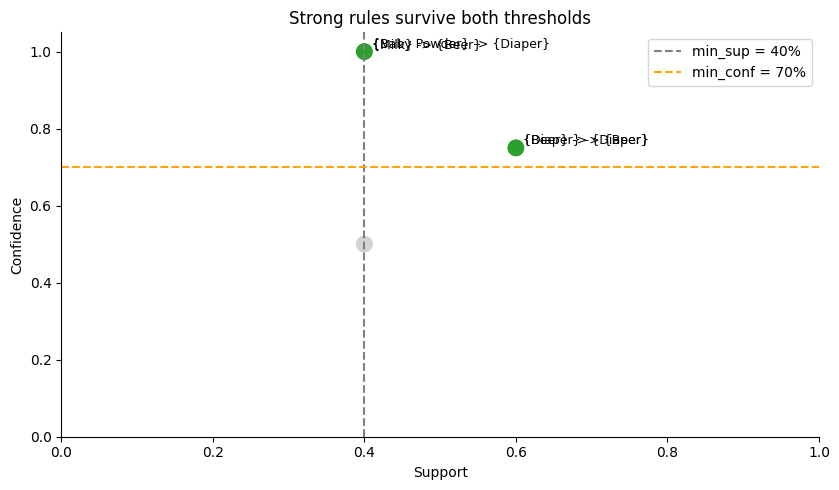

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 5))
if len(rules_df):
    colors = ["#2ca02c" if s else "lightgray" for s in rules_df["Strong rule?"]]
    ax.scatter(rules_df["Support"], rules_df["Confidence"], s=120, c=colors)
    for _, row in rules_df[rules_df["Strong rule?"]].iterrows():
        ax.text(row["Support"] + 0.01, row["Confidence"] + 0.01, row["Rule"], fontsize=9)
ax.axvline(0.4, linestyle="--", color="gray", label="min_sup = 40%")
ax.axhline(0.7, linestyle="--", color="orange", label="min_conf = 70%")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Support")
ax.set_ylabel("Confidence")
ax.set_title("Strong rules survive both thresholds")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Rule network graph


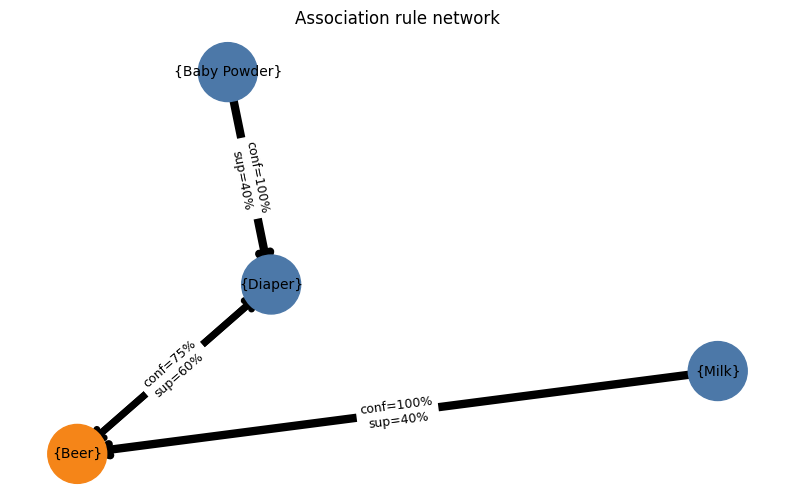

In [15]:
def plot_rule_network(min_sup=0.4, min_conf=0.7):
    _, strong = generate_rules(min_sup, min_conf)
    G = nx.DiGraph()
    if len(strong) == 0:
        print("No strong rules under current thresholds.")
        return

    for _, row in strong.iterrows():
        lhs, rhs = row["Rule"].split(" -> ")
        G.add_node(lhs, kind="lhs")
        G.add_node(rhs, kind="rhs")
        G.add_edge(lhs, rhs, weight=row["Confidence"], support=row["Support"])

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=7)
    node_colors = ["#4C78A8" if G.nodes[n]["kind"] == "lhs" else "#F58518" for n in G.nodes()]
    edge_widths = [2 + 4 * G[u][v]["weight"] for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800)
    nx.draw_networkx_labels(G, pos, font_size=10)
    nx.draw_networkx_edges(G, pos, width=edge_widths, arrows=True, arrowstyle="->", arrowsize=20)
    edge_labels = {(u, v): f"conf={G[u][v]['weight']:.0%}\nsup={G[u][v]['support']:.0%}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
    plt.title("Association rule network")
    plt.axis("off")
    plt.show()

plot_rule_network(0.4, 0.7)


## 10. Interactive thresholds


In [16]:
def interactive_rules(min_sup=0.4, min_conf=0.7):
    _, strong = generate_rules(min_sup, min_conf)
    print(f"min_sup = {min_sup:.0%}, min_conf = {min_conf:.0%}")
    print(f"Number of strong rules: {len(strong)}")
    display(strong)

    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    if len(strong):
        ax.scatter(strong["Support"], strong["Confidence"], s=120, c="#2ca02c")
        for _, row in strong.iterrows():
            ax.text(row["Support"] + 0.01, row["Confidence"] + 0.01, row["Rule"], fontsize=9)
    ax.axvline(min_sup, linestyle="--", color="gray")
    ax.axhline(min_conf, linestyle="--", color="orange")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Support")
    ax.set_ylabel("Confidence")
    ax.set_title("How thresholds affect the surviving rules")
    plt.show()

interact(
    interactive_rules,
    min_sup=FloatSlider(min=0.2, max=0.8, step=0.1, value=0.4, description="min_sup"),
    min_conf=FloatSlider(min=0.4, max=1.0, step=0.05, value=0.7, description="min_conf")
);


interactive(children=(FloatSlider(value=0.4, description='min_sup', max=0.8, min=0.2), FloatSlider(value=0.7, …